In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torchvision import transforms
from PIL import Image
import os, glob, gc
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import warnings
warnings.filterwarnings('ignore')

In [3]:
IMG_SIZE    = 128
BATCH_SIZE  = 16  
NUM_EPOCHS  = 100
LR          = 0.0002
BETAS       = (0.5, 0.999)
L1_LAMBDA   = 100
VIZ_EVERY   = 20
SAVE_EVERY  = 5

In [5]:
DATA_DIR='/kaggle/input/datasets/ktaebum/anime-sketch-colorization-pair/data'
TRAIN_DIR=DATA_DIR + '/train'
VAL_DIR=DATA_DIR + '/val'
CHECKPOINT_DIR='/kaggle/working/checkpoints'
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

torch.backends.cudnn.benchmark = True

In [7]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


class AnimeSketchDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.file_list = sorted(glob.glob(os.path.join(root_dir, '*.png')))
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        image = Image.open(self.file_list[idx]).convert('RGB')
        w, h = image.size
        w2 = w // 2

        color_img = image.crop((0, 0, w2, h))
        sketch_img = image.crop((w2, 0, w, h))

        
        image.close()

        if self.transform:
            color_img = self.transform(color_img)
            sketch_img = self.transform(sketch_img)

        return sketch_img, color_img


train_dataset = AnimeSketchDataset(root_dir=TRAIN_DIR, transform=transform)
val_dataset = AnimeSketchDataset(root_dir=VAL_DIR, transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
    persistent_workers=False  
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=False,  
    persistent_workers=False
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Training batches per epoch: {len(train_loader)}")

# quick verification
sketch, color = train_dataset[0]
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sketch.permute(1, 2, 0) * 0.5 + 0.5)
axes[0].set_title('Sketch (Input)')
axes[0].axis('off')
axes[1].imshow(color.permute(1, 2, 0) * 0.5 + 0.5)
axes[1].set_title('Color (Target)')
axes[1].axis('off')
plt.tight_layout()
plt.show()
del sketch, color

Training samples: 14224
Validation samples: 3545
Training batches per epoch: 889


In [8]:
def encoder_block(in_channels, out_channels, use_batchnorm=True):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False)]
    if use_batchnorm:
        layers.append(nn.BatchNorm2d(out_channels))
    layers.append(nn.LeakyReLU(0.2))
    return nn.Sequential(*layers)


def decoder_block(in_channels, out_channels, use_dropout=False):
    layers = [
        nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(out_channels),
    ]
    if use_dropout:
        layers.append(nn.Dropout(0.5))
    layers.append(nn.ReLU())
    return nn.Sequential(*layers)



class UNetGenerator(nn.Module):
    def __init__(self):
        super(UNetGenerator, self).__init__()

      
        self.enc1 = encoder_block(3,   64,  use_batchnorm=False)   
        self.enc2 = encoder_block(64,  128, use_batchnorm=True)    
        self.enc3 = encoder_block(128, 256, use_batchnorm=True)    
        self.enc4 = encoder_block(256, 512, use_batchnorm=True)    
        self.enc5 = encoder_block(512, 512, use_batchnorm=True)    
        self.enc6 = encoder_block(512, 512, use_batchnorm=True)    

      
        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=4, stride=2, padding=1, bias=False),  # 2 -> 1
            nn.ReLU()
        )

        
        self.dec1 = decoder_block(512,  512, use_dropout=True)     # 1  -> 2
        self.dec2 = decoder_block(1024, 512, use_dropout=True)     # 2  -> 4   (512 dec1 + 512 enc6)
        self.dec3 = decoder_block(1024, 512, use_dropout=True)     # 4  -> 8   (512 dec2 + 512 enc5)
        self.dec4 = decoder_block(1024, 256, use_dropout=False)    # 8  -> 16  (512 dec3 + 512 enc4)
        self.dec5 = decoder_block(512,  128, use_dropout=False)    # 16 -> 32  (256 dec4 + 256 enc3)
        self.dec6 = decoder_block(256,  64,  use_dropout=False)    # 32 -> 64  (128 dec5 + 128 enc2)

       
        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, 3, kernel_size=4, stride=2, padding=1),  # 64 -> 128
            nn.Tanh()
        )

    def forward(self, x):
        
        e1 = self.enc1(x)      
        e2 = self.enc2(e1)     
        e3 = self.enc3(e2)     
        e4 = self.enc4(e3)     
        e5 = self.enc5(e4)     
        e6 = self.enc6(e5)     

        
        b = self.bottleneck(e6)    

     
        d1 = self.dec1(b)
        d1 = torch.cat([d1, e6], dim=1)    

        d2 = self.dec2(d1)
        d2 = torch.cat([d2, e5], dim=1)    

        d3 = self.dec3(d2)
        d3 = torch.cat([d3, e4], dim=1)    

        d4 = self.dec4(d3)
        d4 = torch.cat([d4, e3], dim=1)    

        d5 = self.dec5(d4)
        d5 = torch.cat([d5, e2], dim=1)    

        d6 = self.dec6(d5)
        d6 = torch.cat([d6, e1], dim=1)    

        return self.final(d6)



def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, mean=0.0, std=0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, mean=1.0, std=0.02)  
        nn.init.constant_(m.bias, 0)



generator = UNetGenerator()
generator.apply(init_weights)


test_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
test_output = generator(test_input)
print(f"Generator input shape:  {test_input.shape}")   
print(f"Generator output shape: {test_output.shape}")  


total_params = sum(p.numel() for p in generator.parameters())
print(f"Generator parameters: {total_params:,}")

Generator input shape:  torch.Size([1, 3, 128, 128])
Generator output shape: torch.Size([1, 3, 128, 128])
Generator parameters: 41,828,995


In [9]:
class PatchGANDiscriminator(nn.Module):
    def __init__(self):
        super(PatchGANDiscriminator, self).__init__()

        self.model = nn.Sequential(
           
            nn.Conv2d(6, 64, kernel_size=4, stride=2, padding=1),       
            nn.LeakyReLU(0.2, inplace=True),

           
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),    
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),   
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            
            nn.Conv2d(256, 512, kernel_size=4, stride=1, padding=1, bias=False),  
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=1)            
        )

    def forward(self, sketch, image):
        x = torch.cat([sketch, image], dim=1)
        return self.model(x)



discriminator = PatchGANDiscriminator()
discriminator.apply(init_weights)

test_sketch = torch.randn(1, 3, 256, 256)
test_image = torch.randn(1, 3, 256, 256)
test_pred = discriminator(test_sketch, test_image)
print(f"Discriminator input:  sketch {test_sketch.shape} + image {test_image.shape}")
print(f"Discriminator output: {test_pred.shape}")  

total_params_d = sum(p.numel() for p in discriminator.parameters())
print(f"Discriminator parameters: {total_params_d:,}")

Discriminator input:  sketch torch.Size([1, 3, 256, 256]) + image torch.Size([1, 3, 256, 256])
Discriminator output: torch.Size([1, 1, 30, 30])
Discriminator parameters: 2,768,705


In [10]:
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs with DataParallel")
    generator = nn.DataParallel(generator)
    discriminator = nn.DataParallel(discriminator)


generator = generator.to(device)
discriminator = discriminator.to(device)


adversarial_loss = nn.BCEWithLogitsLoss()


reconstruction_loss = nn.L1Loss()


optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=BETAS)
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=BETAS)


scaler_G = GradScaler()
scaler_D = GradScaler()

print("Models, losses, and optimizers ready.")
print(f"Generator on: {next(generator.parameters()).device}")
print(f"Discriminator on: {next(discriminator.parameters()).device}")

Using 2 GPUs with DataParallel
Models, losses, and optimizers ready.
Generator on: cuda:0
Discriminator on: cuda:0


In [11]:
from huggingface_hub import hf_hub_download
from kaggle_secrets import UserSecretsClient
import torch, torch.nn as nn

HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
REPO_ID         = 'adeelumar17/pix2pix'
CHECKPOINT_FILE = 'checkpoint_epoch_90.pth'

print(f"Downloading {CHECKPOINT_FILE} from HuggingFace...")
ckpt_path = hf_hub_download(
    repo_id   = REPO_ID,
    filename  = CHECKPOINT_FILE,
    repo_type = 'model',
    token     = HF_TOKEN,
    local_dir = '/kaggle/working'
)
print(f"Downloaded to: {ckpt_path}")

checkpoint = torch.load(ckpt_path, map_location=device)

def strip_module_prefix(state_dict):
    new_state_dict = {}
    for k, v in state_dict.items():
        new_key = k.replace('module.', '', 1)  
        new_state_dict[new_key] = v
    return new_state_dict

g = generator.module     if isinstance(generator,     nn.DataParallel) else generator
d = discriminator.module if isinstance(discriminator, nn.DataParallel) else discriminator

g.load_state_dict(strip_module_prefix(checkpoint['generator_state_dict']))
d.load_state_dict(strip_module_prefix(checkpoint['discriminator_state_dict']))
optimizer_G.load_state_dict(checkpoint['optimizer_G_state_dict'])
optimizer_D.load_state_dict(checkpoint['optimizer_D_state_dict'])
g_losses    = checkpoint['g_losses']
d_losses    = checkpoint['d_losses']
start_epoch = checkpoint['epoch']

print(f"✓ Generator loaded")
print(f"✓ Discriminator loaded")
print(f"✓ Optimizers loaded")
print(f"✓ Loss history loaded  —  {len(g_losses)} epochs recorded")
print(f"✓ Resuming from epoch {start_epoch} → training will run {start_epoch} to {NUM_EPOCHS}")
print(f"\nGenerator on:     {next(generator.parameters()).device}")
print(f"Discriminator on: {next(discriminator.parameters()).device}")

checkpoint_epoch_90.pth:   0%|          | 0.00/535M [00:00<?, ?B/s]

Downloaded to: /kaggle/working/checkpoint_epoch_90.pth
✓ Generator loaded
✓ Discriminator loaded
✓ Optimizers loaded
✓ Loss history loaded  —  69 epochs recorded
✓ Resuming from epoch 90 → training will run 90 to 100

Generator on:     cuda:0
Discriminator on: cuda:0


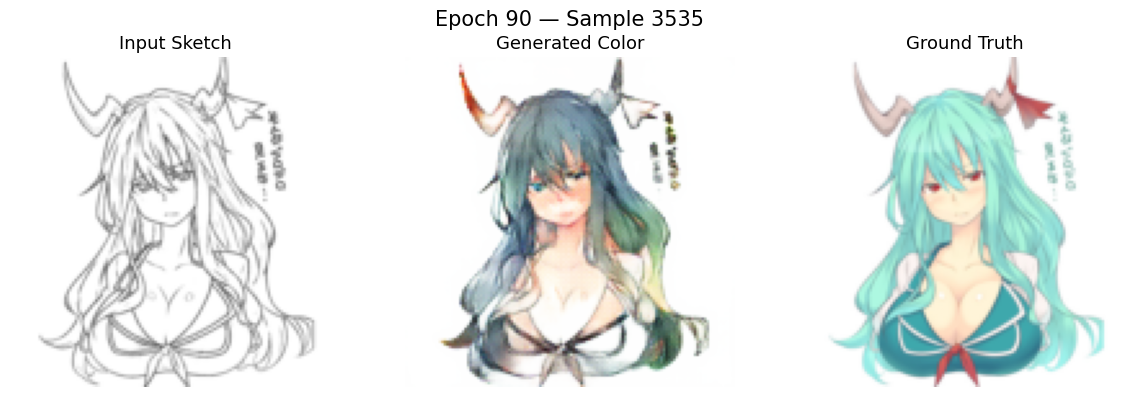

In [12]:
import matplotlib.pyplot as plt
from IPython.display import display
import io
import torch


sample_idx = len(val_dataset)-10  

generator.eval()
with torch.no_grad():
    sketch, real = val_dataset[sample_idx]
    sketch_input = sketch.unsqueeze(0).to(device)
    generated    = generator(sketch_input)


sketch_vis = (sketch.permute(1, 2, 0) * 0.5 + 0.5).clamp(0, 1).numpy()
real_vis   = (real.permute(1, 2, 0)   * 0.5 + 0.5).clamp(0, 1).numpy()
gen_vis    = (generated.squeeze(0).cpu().permute(1, 2, 0) * 0.5 + 0.5).clamp(0, 1).numpy()


fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(sketch_vis);  axes[0].set_title('Input Sketch',    fontsize=13); axes[0].axis('off')
axes[1].imshow(gen_vis);     axes[1].set_title('Generated Color', fontsize=13); axes[1].axis('off')
axes[2].imshow(real_vis);    axes[2].set_title('Ground Truth',    fontsize=13); axes[2].axis('off')

plt.suptitle(f'Epoch {start_epoch} — Sample {sample_idx}', fontsize=15)
plt.tight_layout()
display(fig)      
plt.close(fig)    

In [ ]:
start_epoch = start_epoch if 'start_epoch' in dir() else 0
for epoch in range(start_epoch,NUM_EPOCHS):
    generator.train()
    discriminator.train()
    g_epoch_loss = d_epoch_loss = 0.0

    for i, (sketches, real_images) in enumerate(train_loader):
        sketches    = sketches.to(device, non_blocking=True)
        real_images = real_images.to(device, non_blocking=True)

       
        optimizer_D.zero_grad(set_to_none=True)
        with autocast():
            real_pred    = discriminator(sketches, real_images)
            loss_D_real  = adversarial_loss(real_pred, torch.ones_like(real_pred))
            fake_images  = generator(sketches).detach()  
            fake_pred    = discriminator(sketches, fake_images)
            loss_D_fake  = adversarial_loss(fake_pred, torch.zeros_like(fake_pred))
            d_loss       = (loss_D_real + loss_D_fake) / 2

        scaler_D.scale(d_loss).backward()
        scaler_D.step(optimizer_D)
        scaler_D.update()
        d_epoch_loss += d_loss.item()

       
        optimizer_G.zero_grad(set_to_none=True)
        with autocast():
            fake_images  = generator(sketches)
            fake_pred    = discriminator(sketches, fake_images)
            g_adv_loss   = adversarial_loss(fake_pred, torch.ones_like(fake_pred))
            g_l1_loss    = reconstruction_loss(fake_images, real_images)
            g_loss       = g_adv_loss + L1_LAMBDA * g_l1_loss

        scaler_G.scale(g_loss).backward()
        scaler_G.step(optimizer_G)
        scaler_G.update()
        g_epoch_loss += g_loss.item()

        

        if (i + 1) % 100 == 0:
            print(f"  Epoch [{epoch+1}/{NUM_EPOCHS}] Batch [{i+1}/{len(train_loader)}] "
                  f"D: {d_epoch_loss/(i+1):.4f}  G: {g_epoch_loss/(i+1):.4f}")


    avg_d = d_epoch_loss / len(train_loader)
    avg_g = g_epoch_loss / len(train_loader)
    d_losses.append(avg_d)
    g_losses.append(avg_g)
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | D: {avg_d:.4f} | G: {avg_g:.4f}")

    
    gc.collect()
    torch.cuda.empty_cache()

   
    if (epoch + 1) % SAVE_EVERY == 0:
        torch.save({
            'epoch': epoch + 1,
            'generator_state_dict':     generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'optimizer_G_state_dict':   optimizer_G.state_dict(),
            'optimizer_D_state_dict':   optimizer_D.state_dict(),
            'g_losses': g_losses,
            'd_losses': d_losses,
        }, os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{epoch+1}.pth'))
        print(f"  -> Checkpoint saved at epoch {epoch+1}")

    
    if (epoch + 1) % VIZ_EVERY == 0:
        generator.eval()
        with torch.no_grad():
            sample_sketches, sample_reals = next(iter(val_loader))
            sample_sketches = sample_sketches.to(device)
            sample_fakes    = generator(sample_sketches).cpu()
            sample_sketches = sample_sketches.cpu()

        fig, axes = plt.subplots(3, 4, figsize=(16, 12))
        for j in range(4):
            axes[0, j].imshow((sample_sketches[j].permute(1,2,0) * 0.5 + 0.5).clamp(0,1))
            axes[0, j].set_title('Sketch');  axes[0, j].axis('off')
            axes[1, j].imshow((sample_fakes[j].permute(1,2,0) * 0.5 + 0.5).clamp(0,1))
            axes[1, j].set_title('Generated'); axes[1, j].axis('off')
            axes[2, j].imshow((sample_reals[j].permute(1,2,0) * 0.5 + 0.5).clamp(0,1))
            axes[2, j].set_title('Ground Truth'); axes[2, j].axis('off')

        plt.suptitle(f'Epoch {epoch+1}')
        plt.tight_layout()
        plt.savefig(f'/kaggle/working/samples_epoch_{epoch+1}.png', 
                    dpi=100, bbox_inches='tight')
        plt.close(fig)   
        del sample_sketches, sample_fakes, sample_reals
        gc.collect()
        torch.cuda.empty_cache()
        generator.train()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(range(1, len(g_losses) + 1), g_losses, color='steelblue', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Generator Loss vs Epochs')
axes[0].grid(True, alpha=0.3)


axes[1].plot(range(1, len(d_losses) + 1), d_losses, color='indianred', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Discriminator Loss vs Epochs')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_plots.png', dpi=150, bbox_inches='tight')
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(range(1, len(g_losses) + 1), g_losses, label='Generator', color='steelblue', linewidth=1.5)
plt.plot(range(1, len(d_losses) + 1), d_losses, label='Discriminator', color='indianred', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Generator vs Discriminator Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Final Generator Loss:     {g_losses[-1]:.4f}")
print(f"Final Discriminator Loss: {d_losses[-1]:.4f}")

In [ ]:
def denormalize(tensor):
    """Convert from [-1,1] range back to [0,1] for metric computation."""
    return (tensor + 1.0) / 2.0


generator.eval()
ssim_scores = []
psnr_scores = []

print("Computing SSIM and PSNR on validation set...")

with torch.no_grad():
    for i, (sketches, real_images) in enumerate(val_loader):
        sketches = sketches.to(device)
        real_images = real_images.to(device)

       
        generated = generator(sketches)

        
        gen_np = denormalize(generated).cpu().numpy()
        real_np = denormalize(real_images).cpu().numpy()

        
        for j in range(gen_np.shape[0]):
            
            gen_img = gen_np[j].transpose(1, 2, 0).clip(0, 1)
            real_img = real_np[j].transpose(1, 2, 0).clip(0, 1)

            
            ssim_val = ssim(real_img, gen_img, data_range=1.0, channel_axis=2)
            ssim_scores.append(ssim_val)

            
            psnr_val = psnr(real_img, gen_img, data_range=1.0)
            psnr_scores.append(psnr_val)

 
    if (i + 1) % 10 == 0:
        print(f"  Processed {(i+1) * BATCH_SIZE} images...")

print("=" * 50)
print(f"Evaluated on {len(ssim_scores)} images")
print(f"Average SSIM: {np.mean(ssim_scores):.4f} (+/- {np.std(ssim_scores):.4f})")
print(f"Average PSNR: {np.mean(psnr_scores):.2f} dB (+/- {np.std(psnr_scores):.2f})")
print("=" * 50)

In [ ]:
def visualize_results(gen, loader, num_samples=10):
    """Display input sketch, generated output, and ground truth side by side."""
    gen.eval()

    
    sketches, real_images = next(iter(loader))
    sketches = sketches.to(device)

    with torch.no_grad():
        generated = gen(sketches)

   
    sketches_vis = (sketches.cpu() * 0.5 + 0.5).clamp(0, 1)
    generated_vis = (generated.cpu() * 0.5 + 0.5).clamp(0, 1)
    real_vis = (real_images * 0.5 + 0.5).clamp(0, 1)

    
    num_samples = min(num_samples, sketches_vis.size(0))

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

    
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(num_samples):
      
        axes[i, 0].imshow(sketches_vis[i].permute(1, 2, 0))
        axes[i, 0].set_title('Input Sketch', fontsize=12)
        axes[i, 0].axis('off')

        
        axes[i, 1].imshow(generated_vis[i].permute(1, 2, 0))
        axes[i, 1].set_title('Generated Output', fontsize=12)
        axes[i, 1].axis('off')

        
        axes[i, 2].imshow(real_vis[i].permute(1, 2, 0))
        axes[i, 2].set_title('Ground Truth', fontsize=12)
        axes[i, 2].axis('off')

    plt.suptitle('Pix2Pix Results: Sketch to Colorized Anime', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig('generated_samples.png', dpi=150, bbox_inches='tight')
    plt.show()



visualize_results(generator, val_loader, num_samples=10)

In [ ]:
!pip install huggingface_hub --quiet
from huggingface_hub import HfApi, login, create_repo, list_repo_files
import io, torch, torch.nn as nn
from kaggle_secrets import UserSecretsClient

HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
login(token=HF_TOKEN, add_to_git_credential=False)
api     = HfApi()
REPO_ID = 'adeelumar17/pix2pix'


create_repo(
    repo_id   = REPO_ID,
    repo_type = 'model',
    private   = True,
    exist_ok  = True
)
print(f'Repo ready: https://huggingface.co/{REPO_ID}')


buf = io.BytesIO()
g = generator.module     if isinstance(generator,     nn.DataParallel) else generator
d = discriminator.module if isinstance(discriminator, nn.DataParallel) else discriminator


current_epoch = 100

torch.save({
    'epoch'                    : current_epoch,
    'generator_state_dict'     : g.state_dict(),       
    'discriminator_state_dict' : d.state_dict(),
    'optimizer_G_state_dict'   : optimizer_G.state_dict(),
    'optimizer_D_state_dict'   : optimizer_D.state_dict(),
    'g_losses'                 : g_losses,            
    'd_losses'                 : d_losses,
}, buf)

size_mb = buf.tell() / 1e6
buf.seek(0)
print(f'Checkpoint size: {size_mb:.0f} MB — uploading...')


api.upload_file(
    path_or_fileobj = buf,
    path_in_repo    = f'checkpoint_epoch_{current_epoch}.pth',  
    repo_id         = REPO_ID,
    repo_type       = 'model',
    commit_message  = f'checkpoint upload — epoch {current_epoch}'
)
print(f'Upload complete: https://huggingface.co/{REPO_ID}')
print('Files in your HuggingFace repo:')
for f in list_repo_files(repo_id=REPO_ID, repo_type='model', token=HF_TOKEN):
    print(f'  {f}')

In [ ]:
!pip install huggingface_hub --quiet
from huggingface_hub import HfApi, login, create_repo, list_repo_files
from kaggle_secrets import UserSecretsClient

HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
login(token=HF_TOKEN, add_to_git_credential=False)
api     = HfApi()
REPO_ID = 'adeelumar17/pix2pix'

create_repo(repo_id=REPO_ID, repo_type='model', private=True, exist_ok=True)
print(f'Repo ready: https://huggingface.co/{REPO_ID}')


checkpoint_to_upload = '/kaggle/working/checkpoints/checkpoint_epoch_90.pth'

api.upload_file(
    path_or_fileobj = checkpoint_to_upload,
    path_in_repo    = 'checkpoint_epoch_90.pth',
    repo_id         = REPO_ID,
    repo_type       = 'model',
    commit_message  = 'checkpoint upload — epoch 85'
)
print(f'Upload complete: https://huggingface.co/{REPO_ID}')
print('Files in your HuggingFace repo:')
for f in list_repo_files(repo_id=REPO_ID, repo_type='model', token=HF_TOKEN):
    print(f'  {f}')